In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression

In [3]:
# Data laoding
orders_df = pd.read_excel('Superstore_Data.xlsx', sheet_name='Orders')
returns_df = pd.read_excel('Superstore_Data.xlsx', sheet_name='Returns')

In [4]:
# Date Formatting
def clean_date(value):
    if pd.isna(value): return None
    if isinstance(value, (pd.Timestamp, datetime.datetime)): return value
    try:
        return datetime.datetime(1899, 12, 30) + datetime.timedelta(days=float(value))
    except:
        return pd.to_datetime(value, errors='coerce')

orders_df['Order Date'] = orders_df['Order Date'].apply(clean_date)

In [5]:
# --- Processing returns ---
# Should any returns occur, this sum should not be counted.
merged_df = orders_df.merge(returns_df, on='Order ID', how='left')
merged_df['Returned'] = merged_df['Returned'].fillna('No')

In [6]:
# Create "Net Sales" and "Net Profit" fields
# If returned (Returned='Yes'), set the amount to zero
merged_df['Sales_Net'] = merged_df.apply(lambda x: 0 if x['Returned'] == 'Yes' else x['Sales'], axis=1)
merged_df['Profit_Net'] = merged_df.apply(lambda x: 0 if x['Returned'] == 'Yes' else x['Profit'], axis=1)
print("--- Data Cleansing Report ---")
print(f"Gross sales: ${orders_df['Sales'].sum():,.0f}")
print(f"Net sales excluding returns: ${merged_df['Sales_Net'].sum():,.0f}")
print(f"Losses incurred due to returns: ${orders_df['Sales'].sum() - merged_df['Sales_Net'].sum():,.0f}")

--- Data Cleansing Report ---
Gross sales: $2,297,201
Net sales excluding returns: $2,116,697
Losses incurred due to returns: $180,504


In [7]:
# Feature Engineering
def build_features(df, cutoff_date, target_year_days=365):
    # 1. Features
    history = df[df['Order Date'] <= cutoff_date].copy()
    
    # 2. Target Label
    target_start = cutoff_date + datetime.timedelta(days=1)
    target_end = cutoff_date + datetime.timedelta(days=target_year_days)
    future = df[(df['Order Date'] >= target_start) & (df['Order Date'] <= target_end)]

    # 3. Aggregate Computation Features
    # Basic RFM
    features = history.groupby('Customer ID').agg({
        'Order Date': lambda x: (cutoff_date - x.max()).days, # Recency
        'Order ID': 'nunique',                                 # Frequency
        'Sales_Net': ['sum', 'mean'],                          # Monetary (Total & Avg)
        'Profit_Net': 'sum',                                   # Total Profit
        'Discount': 'mean',                                    # Avg Discount
        'Quantity': 'sum'                                      # Total Quantity
    }).reset_index()
    
    # Rename column
    features.columns = ['Customer ID', 'Recency', 'Frequency', 'Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Discount', 'Total_Quantity']
    
    # Derived attribute: Tenure (customer tenure/lifecycle duration)
    first_buy = history.groupby('Customer ID')['Order Date'].min().reset_index()
    features = features.merge(first_buy, on='Customer ID', how='left')
    features['Tenure'] = (cutoff_date - features['Order Date']).dt.days # Cutoff - First Buy
    features.drop(columns=['Order Date'], inplace=True)

    # 4. Calculated label (true value over the coming year)
    target_val = future.groupby('Customer ID')['Sales_Net'].sum().reset_index()
    target_val.columns = ['Customer ID', 'Next_Year_Value']
    
    # Merge (using the feature table as the primary source, for all customers)
    final_df = features.merge(target_val, on='Customer ID', how='left')
    final_df['Next_Year_Value'] = final_df['Next_Year_Value'].fillna(0) # Not buying means zero.
    
    return final_df

In [8]:
# Construction of the training set (based on the split at the end of 2017)
train_cutoff = datetime.datetime(2017, 12, 31)
train_df = build_features(merged_df, train_cutoff)

# Constructing the forecast set (based on a cut-off at the end of 2018, forecasting 2019)
pred_cutoff = datetime.datetime(2018, 12, 31)
pred_df = build_features(merged_df, pred_cutoff)

print(f"\n--- Feature engineering completed ---")
print(f"Number of training set samples: {len(train_df)}")
print(f"Number of samples in the prediction set: {len(pred_df)}")


--- Feature engineering completed ---
Number of training set samples: 782
Number of samples in the prediction set: 793


In [9]:
# LinearRegression
feature_cols = ['Recency', 'Frequency', 'Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Discount', 'Total_Quantity', 'Tenure']
X = train_df[feature_cols]
y = train_df['Next_Year_Value']

# fill NAN
X = X.fillna(0)

# split test train dataset
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# LR
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# evaluate
preds = lr_model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
r2 = r2_score(y_valid, preds)

print(f"\n--- Linear Regression ---")
print(f"RMSE: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


--- Linear Regression ---
RMSE: $1239.61
R2 Score: -0.0130


In [10]:
# LightGBM
feature_cols = ['Recency', 'Frequency', 'Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Discount', 'Total_Quantity', 'Tenure']
X = train_df[feature_cols]
y = train_df['Next_Year_Value']

# Partitioning the validation set
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialise the LightGBM regression model 
lgb_model = LGBMRegressor(
    n_estimators=300, 
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,                     
    reg_lambda=0.1,                    
    random_state=42,
    verbose=-1
)

In [11]:
lgb_model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=6,
              n_estimators=300, random_state=42, reg_alpha=0.1, reg_lambda=0.1,
              subsample=0.8, verbose=-1)

In [12]:
preds = lgb_model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, preds))
r2 = r2_score(y_valid, preds)
print(f"\n--- Predicting 2018 Sales ---")
print(f"RMSE: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


--- Predicting 2018 Sales ---
RMSE: $1317.61
R2 Score: -0.1444


In [1]:
'''
                Next_Year_Sales
Next_Year_Sales         1.000000
Avg_Sales               0.045538
Total_Sales             0.029853
Frequency               0.019383
Total_Quantity         -0.003530
Recency                -0.021854
Tenure                 -0.055322
'''

'\n                Next_Year_Sales\nNext_Year_Sales         1.000000\nAvg_Sales               0.045538\nTotal_Sales             0.029853\nFrequency               0.019383\nTotal_Quantity         -0.003530\nRecency                -0.021854\nTenure                 -0.055322\n'

C:\Users\79472\AppData\Local\Temp\ipykernel_2012\614698797.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_returns = order_level.groupby('Sub-Category').apply(
C:\Users\79472\AppData\Local\Temp\ipykernel_2012\614698797.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_returns.values, y=category_returns.index, ax=axes[2, 1], palette='magma')


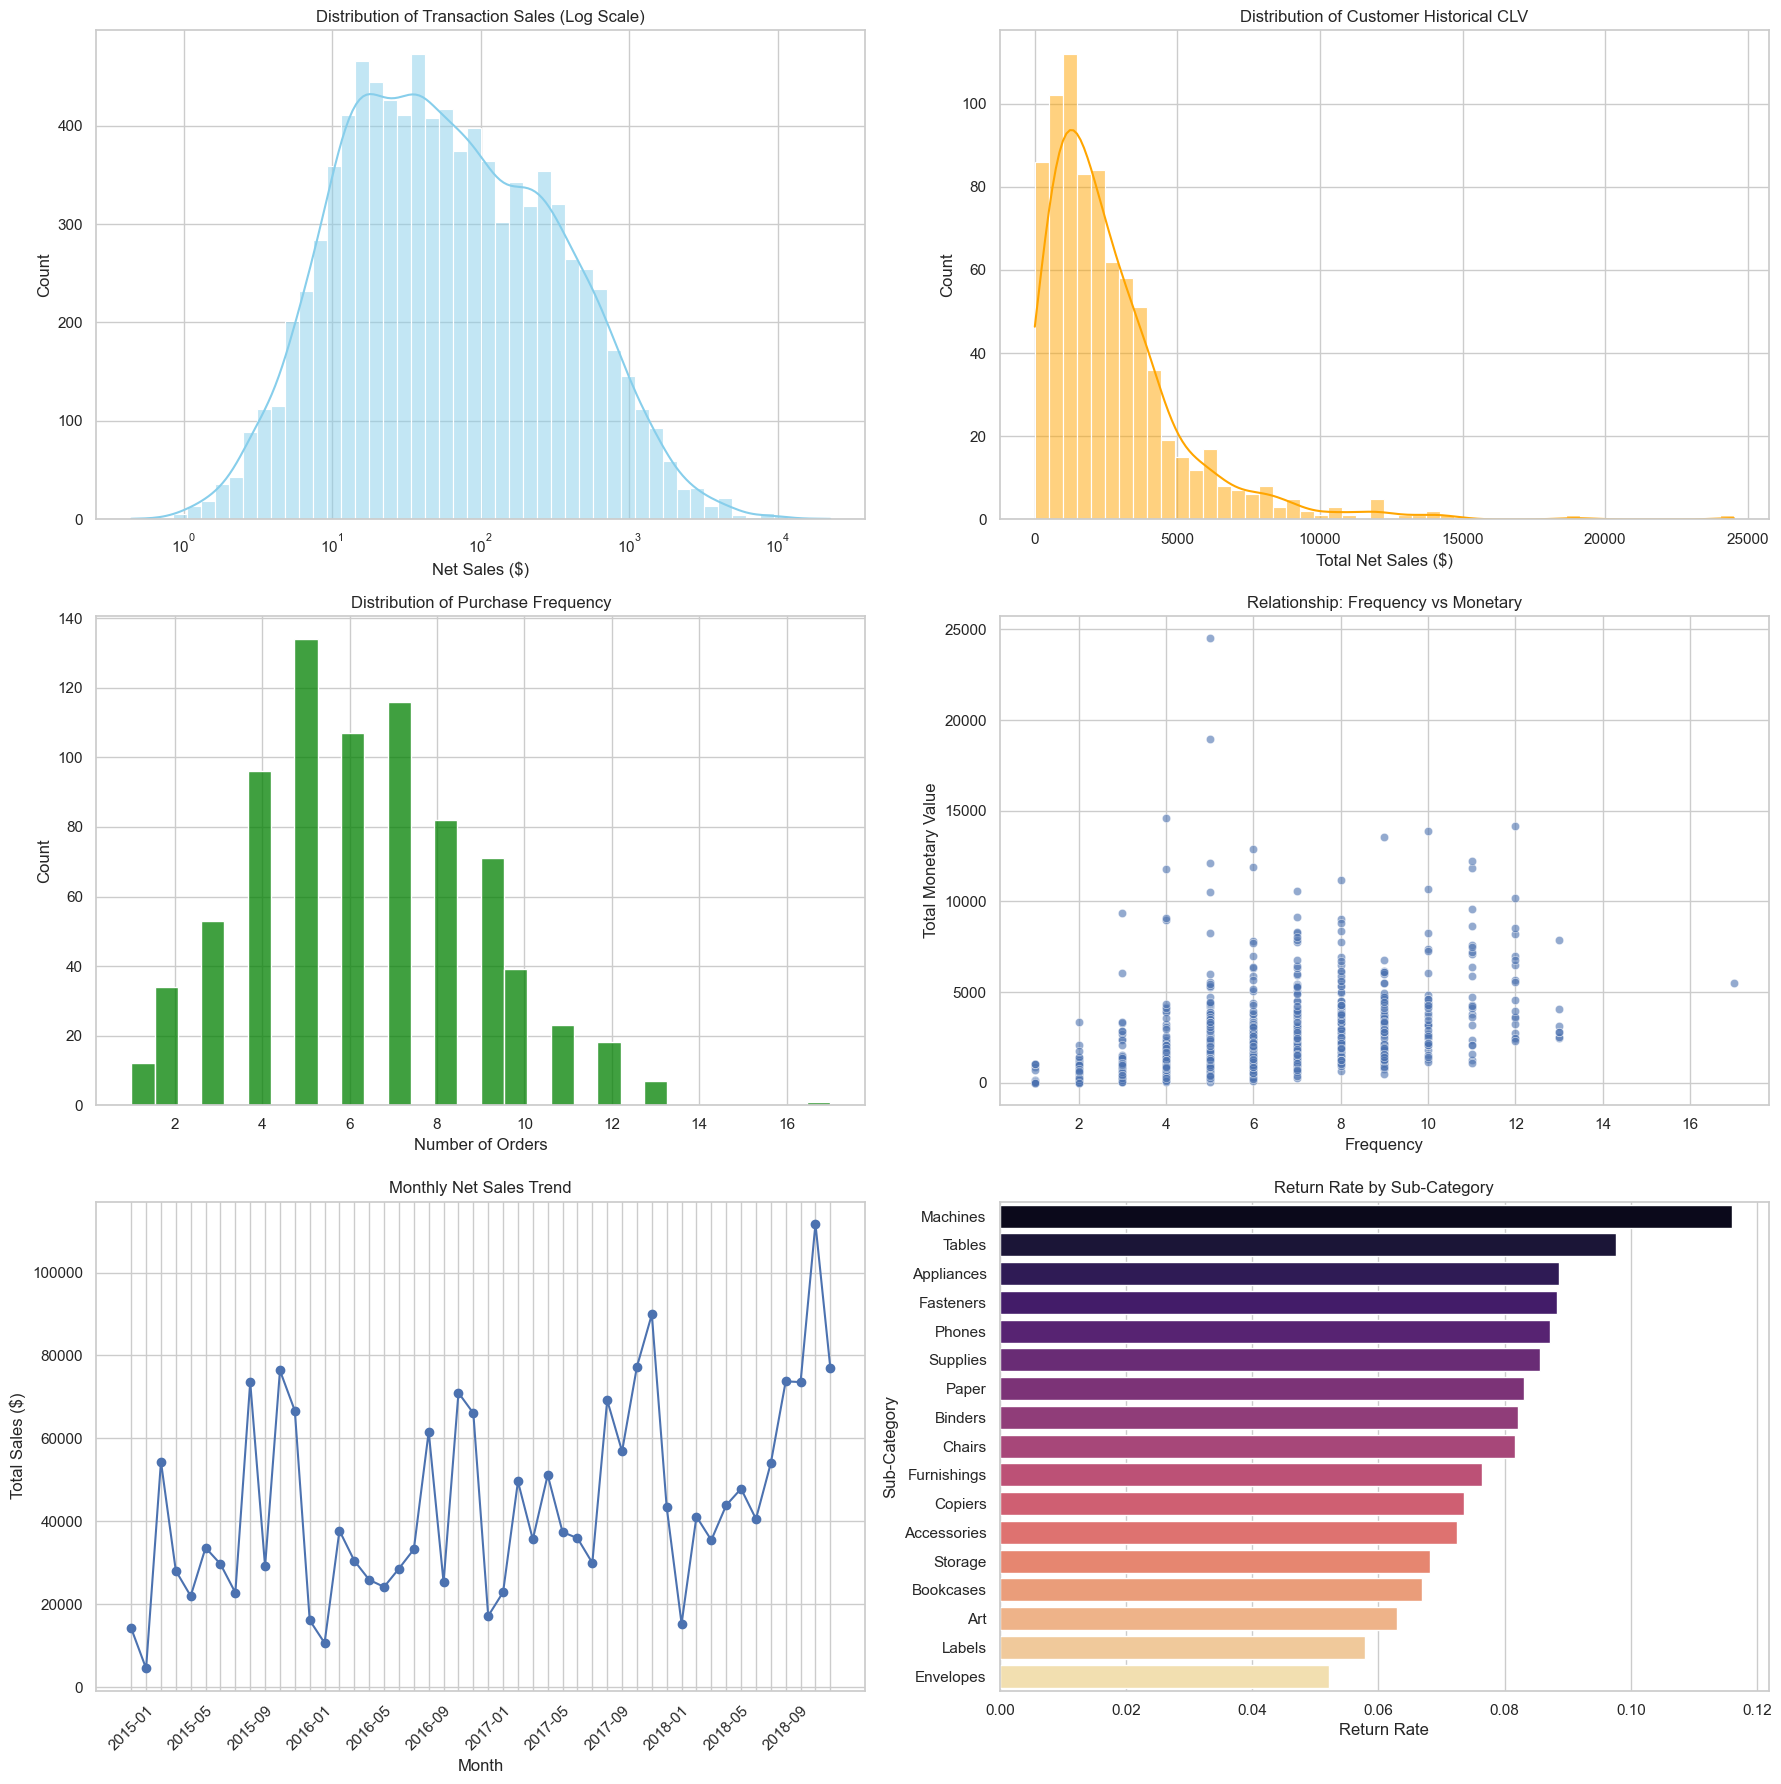

In [14]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Transaction Level
sns.histplot(merged_df[merged_df['Sales_Net'] > 0]['Sales_Net'], bins=50, kde=True, log_scale=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Transaction Sales (Log Scale)')
axes[0, 0].set_xlabel('Net Sales ($)')

# Customer Lifetime Value - Historical
customer_clv = merged_df.groupby('Customer ID')['Sales_Net'].sum()
sns.histplot(customer_clv, bins=50, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Distribution of Customer Historical CLV')
axes[0, 1].set_xlabel('Total Net Sales ($)')

# Frequency
customer_freq = merged_df.groupby('Customer ID')['Order ID'].nunique()
sns.histplot(customer_freq, bins=30, kde=False, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Purchase Frequency')
axes[1, 0].set_xlabel('Number of Orders')

# Frequency vs Monetary
customer_stats = pd.DataFrame({'Frequency': customer_freq, 'Monetary': customer_clv})
sns.scatterplot(data=customer_stats, x='Frequency', y='Monetary', ax=axes[1, 1], alpha=0.6)
axes[1, 1].set_title('Relationship: Frequency vs Monetary')
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Total Monetary Value')

# Time Series
merged_df['Order Month'] = merged_df['Order Date'].dt.to_period('M')
monthly_sales = merged_df.groupby('Order Month')['Sales_Net'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
axes[2, 0].plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
axes[2, 0].set_title('Monthly Net Sales Trend')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('Total Sales ($)')
axes[2, 0].tick_params(axis='x', rotation=45)
# x only
every_nth = 4
for n, label in enumerate(axes[2, 0].xaxis.get_ticklabels()):
    if n % every_nth != 0:
        label.set_visible(False)

# Return Rate Analysis 
order_level = merged_df[['Order ID', 'Sub-Category', 'Returned']].drop_duplicates()
category_returns = order_level.groupby('Sub-Category').apply(
    lambda x: (x['Returned'] == 'Yes').sum() / len(x)
).sort_values(ascending=False)

sns.barplot(x=category_returns.values, y=category_returns.index, ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('Return Rate by Sub-Category')
axes[2, 1].set_xlabel('Return Rate')

plt.tight_layout()
plt.show()